# Free-vocabulary logic labels and metric test (R_COMP FREE, criterion (c))

This notebook demos the **confirmation test of criterion (c)** from an NL→FOL (autoformalization) metric study. It asks one question: with **no gold formula**, does
**cross-family solver consensus** (`c_score_align`) predict whether a candidate FOL formalization is faithful to its sentence better than a
cheap **LLM-as-judge** (gemini flash-lite with rubric A)? The judge is scored in two views: *disguised* (predicates renamed) and *original*.

**What the full artifact did**
- The data is 2,652 free-vocabulary FOL translations of 221 **templated** long rule sentences (9 templates). They come from 10 LLM system slots in 9 model families.
- Metric scores were **sealed before any label existed**.
- Labels came from a prover-based labeller with a two-checker "gloss gate". The gate **failed twice**, so the pre-registered FALLBACK B applied:
  every non-equivalent-but-mapped row became `UNRESOLVED_GLOSS_GATE_FAILED`, there are 0 `CORRECT` rows, and criterion (c) is **NOT_TESTABLE**.
- A **provisional, non-confirmatory** view compares `ERROR_CERT` (y=1, a prover certificate of non-equivalence) against `MAPPED`
  (`UNRESOLVED_GLOSS_GATE_FAILED`, y=0). On the full data, within-template AUROC was c_align 0.801 vs judge (disguised) 0.584, a delta of **+0.217 [0.175, 0.260]**.
  In the original view it was 0.804 vs 0.633, a delta of **+0.171 [0.135, 0.206]**.

**What this notebook runs**
- The original `method.py` is an orchestrator. It calls one script per pre-registered step, and the paid steps are LLM, gloss-gate and audit calls.
  Its code is kept below, but the step scripts are not shipped with this demo, so it only **lists** the steps.
- The `$0` statistical core then runs **verbatim** on a 100-row subset that already carries the sealed scores and labels. That core is
  `confirm/auc_tools.py`, `confirm/analysis_lib.py` and the analysis functions of `confirm/join_and_test.py`. It computes within-template
  (stratified) AUROC, the template-stratified sentence bootstrap, paired AUROC deltas, cross-fitted nesting, and operating points.

Orientation throughout: **higher score = more likely ERROR**.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# --- original method.py imports ---
import argparse
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- imports of the analysis modules (confirm/cc.py, auc_tools.py, analysis_lib.py, join_and_test.py) ---
import hashlib
import json
import math
import time
import types
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# --- notebook-only: visualization ---
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-5/experiment-13/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(len(examples), "rows |", Counter(e["output"] for e in examples))
print("full-run verdict:", data["metadata"]["verdict"])
print(data["metadata"]["demo_subset"])

100 rows | Counter({'UNRESOLVED_GLOSS_GATE_FAILED': 47, 'ERROR_CERT': 43, 'NO_OUTPUT': 7, 'UNPARSEABLE': 3})
full-run verdict: NOT_TESTABLE
100 rows of R_COMP FREE from 18 whole sentences (2 per template, all 9 templates): per sentence 2 ERROR_CERT + 2 MAPPED (=UNRESOLVED_GLOSS_GATE_FAILED) + 1 random labelled row (untouched, both judge views scored), plus 10 UNPARSEABLE/NO_OUTPUT rows of the same sentences so that coverage is visible. Seed 20260924.


## Config

These are the tunable parameters. The original values are in the comments. On the 100-row demo subset even the original values finish in seconds.
- `B`: bootstrap replicates for the template-stratified sentence bootstrap (original `cc.B = 2000`).
- `SEED`: bootstrap seed (original `cc.SEED = 20260924`).
- `N_PERM`: within-template label permutations for the nesting null (original 50; `--quick` used 10).

In [5]:
B = 2000          # original: 2000   (join_and_test.py --quick: 200)
SEED = 20260924   # original: 20260924
N_PERM = 50       # original: 50     (join_and_test.py --quick: 10)

## 1. The pipeline entry point (`method.py`)

`method.py` runs each pre-registered step as its own script: score sealing, preregistration, the gloss gate, the blind audit, the frontier judge,
the analysis, the report and the checks. The paid steps are cached and ledgered. The default is the `$0` tail `analysis,report,checks`.

**Notebook changes (minimal):**
- `WS` is the current directory, because a notebook has no `__file__`.
- `argparse` is replaced by a `steps` argument.
- A step whose script is missing is listed and skipped. The step scripts and their raw inputs are not part of this demo.

The `analysis` step's statistical core is re-run inline in the sections below.

In [6]:
WS = Path(".")  # original: Path(__file__).resolve().parent (relative here so logged paths stay portable)
PY = "python"  # original: sys.executable (short name here for readable logs)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs/method.log", rotation="30 MB", level="DEBUG")

STEPS = {
    "g0": [["confirm/g0_repro.py"]],
    "judge_orig": [["confirm/judge_orig_complete.py"]],
    "scores": [["confirm/scores.py"]],
    "prereg": [["confirm/prereg.py"]],
    "pilot": [["confirm/gloss_pilot.py"]],
    "gate": [["labeller/src/resume_gloss.py", "gate"], ["labeller/src/gate.py", "run", "--half", "B", "--version", "gloss_v2"]],
    "gate_diag": [["confirm/gate_diagnostics.py"]],
    "finalize": [["labeller/src/resume_gloss.py", "finalize", "--version", "gloss_v2"]],
    "audit": [["confirm/audit_blind.py"]],
    "frontier": [["confirm/frontier_judge.py"]],
    "analysis": [["confirm/join_and_test.py"]],
    "report": [["confirm/report.py"]],
    "checks": [["tests/rederive_confirm.py"], ["confirm/write_deviations.py"], ["confirm/final_checks.py"]],
}


@logger.catch(reraise=True)
def main(steps: str = "analysis,report,checks") -> None:  # original: argparse --steps (same default)
    for st in steps.split(","):
        for cmd in STEPS[st]:
            script = WS / cmd[0]
            cwd = script.parent if cmd[0].startswith("confirm/") else (WS / "labeller" if cmd[0].startswith("labeller/") else WS)
            args = [PY, str(script)] + cmd[1:]
            if cmd[0].startswith("labeller/"):
                args = [PY, str(Path(cmd[0]).relative_to("labeller"))] + cmd[1:]
            logger.info(f"[{st}] $ {' '.join(args)}")
            if not script.exists():  # notebook-only: step scripts are not shipped with the demo
                logger.info(f"[{st}] (script not shipped with this demo -> skipped; its core is re-run inline below)")
                continue
            subprocess.run(args, check=True, cwd=cwd)
    logger.info("done")


main(",".join(STEPS))  # list every step in pre-registered order

16:50:17|INFO   |[g0] $ python confirm/g0_repro.py


16:50:17|INFO   |[g0] (script not shipped with this demo -> skipped; its core is re-run inline below)


16:50:17|INFO   |[judge_orig] $ python confirm/judge_orig_complete.py


16:50:17|INFO   |[judge_orig] (script not shipped with this demo -> skipped; its core is re-run inline below)


16:50:17|INFO   |[scores] $ python confirm/scores.py


...

16:50:17|INFO   |[checks] $ python confirm/write_deviations.py


16:50:17|INFO   |[checks] (script not shipped with this demo -> skipped; its core is re-run inline below)


16:50:17|INFO   |[checks] $ python confirm/final_checks.py


16:50:17|INFO   |[checks] (script not shipped with this demo -> skipped; its core is re-run inline below)


16:50:17|INFO   |done


## 2. Shared helpers (`confirm/cc.py`)

- `wilson`: Wilson CI for the operating points.
- `sha1` / `fold_of`: the pre-registered, label-free assignment of each sentence to one of 5 cross-fitting folds.
  In the original, `fold` was stored in the sealed score file. Here it is recomputed with the same formula.

In [7]:
def sha1(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()


def fold_of(sid: str) -> int:
    return int(sha1("rcomp_folds_v1|" + sid), 16) % 5


def wilson(k: int, n: int, z: float = 1.96) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(c - h, 4), round(c + h, 4)]

## 3. Stratified, cluster-weighted AUROC (`confirm/auc_tools.py`, verbatim)

The primary statistic is the **within-template AUROC**. Inside each template, count the ERROR×CORRECT pairs where the ERROR row scores
higher (ties count 0.5), then pool the counts over templates. Comparing only within a template removes template-level confounds.
The bootstrap resamples **sentences** (clusters) with replacement **within each template**. Each row inherits its sentence's multiplicity `k`.

In [8]:
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}

## 4. Analysis statistics (`confirm/analysis_lib.py`, verbatim)

- `Boot`: **one** shared set of bootstrap weights. Every metric and every delta uses the same resamples, so the comparisons are properly paired.
- `auc_block` / `paired_delta`: AUROC(a) − AUROC(b) on rows scored by both metrics, with a bootstrap CI and a two-sided p-value.
- `crossfit_oof` / `nested_block`: does adding metric B to metric A add signal? This fits a cross-fitted logistic model on rank-normalised
  features over 5 sentence folds, then reports [A+B] − [A] with a within-template label-permutation null.
- `op_point` / `thr_at_fa`: recall, false-alarm rate and precision at fixed thresholds.

The only change: the modules are pasted into cells instead of imported. Afterwards they are gathered into an `AL` namespace, so the analysis code below keeps its `AL.` prefix.

In [9]:
class Boot:
    """One set of bootstrap weights over ALL sentences (clusters), resampled within template; shared by every metric,
    population and delta, so that paired comparisons use the SAME resamples."""

    def __init__(self, sentence_ids: list[str], sentence_template: dict, B: int, seed: int):
        self.sids = sorted(sentence_ids)
        self.ix = {s: i for i, s in enumerate(self.sids)}
        cs = np.array([sentence_template[s] for s in self.sids])
        self.W = boot_weights(cs, B, seed)
        self.B = B

    def cl(self, sids) -> np.ndarray:
        return np.array([self.ix[s] for s in sids], dtype=np.int64)


def _arr(df, col):
    return df[col].to_numpy(dtype=float)


def auc_block(df, score: str, boot: Boot, ycol: str = "y", stratum: str = "template_id", with_boot: bool = True) -> dict:
    d = df[df[score].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    out = {"n": int(len(d)), "n_err": int(y.sum()), "n_cor": int((~y).sum()), "n_sent": int(d.sentence_id.nunique()),
           "n_sent_err": int(d[y].sentence_id.nunique()), "n_sent_cor": int(d[~y].sentence_id.nunique())}
    if y.all() or (~y).all() or len(d) == 0:
        out.update(est=None, ci=[None, None], se=None)
        return out
    st = d[stratum].to_numpy() if stratum != "pooled" else np.zeros(len(d))
    A = StratAUC(_arr(d, score), y, st, boot.cl(d.sentence_id))
    out["est"] = A.value()
    if with_boot:
        bs = np.array([A.value(boot.W[b]) for b in range(boot.B)])
        bs = bs[~np.isnan(bs)]
        out["ci"] = [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]
        out["se"] = float(np.std(bs, ddof=1))
    return out


def paired_delta(df, a: str, b: str, boot: Boot, ycol: str = "y", stratum: str = "template_id") -> dict:
    """AUROC_within(a) - AUROC_within(b) on rows where both are scored, same bootstrap weights."""
    d = df[df[a].notna() & df[b].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    out = {"a": a, "b": b, "n": int(len(d)), "n_err": int(y.sum()), "n_cor": int((~y).sum()), "n_sent": int(d.sentence_id.nunique())}
    if len(d) == 0 or y.all() or (~y).all():
        out.update(delta=None, ci=[None, None], p_two_sided=None, auroc_a=None, auroc_b=None)
        return out
    st = d[stratum].to_numpy() if stratum != "pooled" else np.zeros(len(d))
    cl = boot.cl(d.sentence_id)
    A = StratAUC(_arr(d, a), y, st, cl)
    Bm = StratAUC(_arr(d, b), y, st, cl)
    ea, eb = A.value(), Bm.value()
    ba = np.array([A.value(boot.W[i]) for i in range(boot.B)])
    bb = np.array([Bm.value(boot.W[i]) for i in range(boot.B)])
    dd = ba - bb
    ok = ~np.isnan(dd)
    dd, ba, bb = dd[ok], ba[ok], bb[ok]
    out.update(auroc_a=ea, auroc_b=eb, auroc_a_ci=[float(np.percentile(ba, 2.5)), float(np.percentile(ba, 97.5))],
               auroc_b_ci=[float(np.percentile(bb, 2.5)), float(np.percentile(bb, 97.5))], delta=ea - eb,
               ci=[float(np.percentile(dd, 2.5)), float(np.percentile(dd, 97.5))], se=float(np.std(dd, ddof=1)),
               p_two_sided=float(min(1.0, 2 * min((dd <= 0).mean(), (dd >= 0).mean()))), ci_lower_gt_0=bool(np.percentile(dd, 2.5) > 0),
               ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])
    return out


def delta_boot_vector(df, a: str, b: str, boot: Boot, ycol: str = "y") -> tuple[float, np.ndarray]:
    d = df[df[a].notna() & df[b].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    st = d.template_id.to_numpy()
    cl = boot.cl(d.sentence_id)
    A, Bm = StratAUC(_arr(d, a), y, st, cl), StratAUC(_arr(d, b), y, st, cl)
    return A.value() - Bm.value(), np.array([A.value(boot.W[i]) - Bm.value(boot.W[i]) for i in range(boot.B)])


def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


# ------------------------------------------------------------------------------------------ nesting
def _ecdf_map(train: np.ndarray, x: np.ndarray) -> np.ndarray:
    s = np.sort(train)
    lo = np.searchsorted(s, x, side="left")
    hi = np.searchsorted(s, x, side="right")
    return (lo + hi) / (2.0 * len(s))


def crossfit_oof(d, features: list[str], ycol: str = "y", C: float = 1.0) -> np.ndarray:
    """5 sentence folds (d.fold); features rank-normalised by the TRAIN fold's ECDF; logistic OOF probabilities."""
    y = d[ycol].to_numpy().astype(int)
    out = np.full(len(d), np.nan)
    folds = d.fold.to_numpy()
    X = d[features].to_numpy(dtype=float)
    for f in range(5):
        te, tr = folds == f, folds != f
        if te.sum() == 0 or len(set(y[tr])) < 2:
            continue
        Xtr = np.column_stack([_ecdf_map(X[tr, j], X[tr, j]) for j in range(X.shape[1])])
        Xte = np.column_stack([_ecdf_map(X[tr, j], X[te, j]) for j in range(X.shape[1])])
        m = LogisticRegression(C=C, max_iter=1000).fit(Xtr, y[tr])
        out[te] = m.predict_proba(Xte)[:, 1]
    return out


def nested_block(df, base: list[str], add: list[str], boot: Boot, ycol: str = "y", n_perm: int = 50, seed: int = 20260924) -> dict:
    """[base+add] - [base] within-template AUROC of cross-fitted OOF predictions, bootstrap over sentences on the fixed
    OOF predictions (no refit per replicate), plus a within-template label-permutation null with refits."""
    cols = base + add
    d = df[df[cols].notna().all(axis=1) & df[ycol].notna()].copy()
    d["_p_base"] = crossfit_oof(d, base, ycol)
    d["_p_full"] = crossfit_oof(d, cols, ycol)
    r = paired_delta(d, "_p_full", "_p_base", boot, ycol)
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        dp = d.copy()
        yp = dp[ycol].to_numpy().copy()
        for t in np.unique(dp.template_id):
            m = dp.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        dp["_yp"] = yp
        dp["_pb"] = crossfit_oof(dp, base, "_yp")
        dp["_pf"] = crossfit_oof(dp, cols, "_yp")
        yb = dp._yp.to_numpy().astype(bool)
        st, cl = dp.template_id.to_numpy(), boot.cl(dp.sentence_id)
        null.append(StratAUC(dp._pf.to_numpy(), yb, st, cl).value() - StratAUC(dp._pb.to_numpy(), yb, st, cl).value())
    null = np.array(null)
    return {"model_base": base, "model_full": cols, "n": int(len(d)), "auroc_full": r.get("auroc_a"), "auroc_base": r.get("auroc_b"),
            "delta": r.get("delta"), "ci": r.get("ci"), "p_two_sided": r.get("p_two_sided"),
            "perm_null_p95": float(np.percentile(null, 95)), "perm_null_mean": float(null.mean()), "n_perm": n_perm,
            "delta_gt_null_p95": bool(r.get("delta") is not None and r["delta"] > np.percentile(null, 95)),
            "note": "bootstrap over sentences on fixed OOF predictions (no refit per replicate); permutation null refits"}


# ------------------------------------------------------------------------------------------ operating points
def op_point(df, score: str, thr: float, ycol: str = "y") -> dict:
    # original: from cc import wilson  (defined in the helpers cell above)
    d = df[df[score].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    f = d[score].to_numpy() > thr
    tp, fp = int((f & y).sum()), int((f & ~y).sum())
    return {"threshold_gt": thr, "n_err": int(y.sum()), "n_cor": int((~y).sum()), "recall": tp / max(y.sum(), 1),
            "recall_ci": wilson(tp, int(y.sum())), "FA": fp / max((~y).sum(), 1), "FA_ci": wilson(fp, int((~y).sum())),
            "precision": tp / max(tp + fp, 1), "precision_ci": wilson(tp, tp + fp), "n_flagged": int(f.sum())}


def thr_at_fa(df, score: str, fa: float = 0.10, ycol: str = "y") -> dict:
    """Coarse scores tie heavily, so FA = 0.10 is rarely achievable exactly: return the two achievable thresholds that
    bracket it (rule 'score > t'): t_le = smallest t with FA <= fa, t_gt = largest t with FA > fa."""
    d = df[df[score].notna() & df[ycol].notna()]
    neg = d[~d[ycol].astype(bool)][score].to_numpy()
    cands = np.unique(np.concatenate([neg, [neg.min() - 1e-9]]))
    fas = np.array([(neg > t).mean() for t in cands])
    le = cands[fas <= fa]
    gt = cands[fas > fa]
    return {"t_le": float(le.min()) if len(le) else None, "t_gt": float(gt.max()) if len(gt) else None}


# notebook-only: namespace so the join_and_test.py code below keeps its `AL.` prefix
AL = types.SimpleNamespace(Boot=Boot, auc_block=auc_block, paired_delta=paired_delta, delta_boot_vector=delta_boot_vector, holm=holm,
                           crossfit_oof=crossfit_oof, nested_block=nested_block, op_point=op_point, thr_at_fa=thr_at_fa)

## 5. Join sealed scores to labels (`join_and_test.py::load_joined`, adapted)

In the original, `load_joined()` reads the sealed score file and the sealed label file, but only after both SHA-256 seals verify.
Here the joined rows come from the demo data instead. Each example carries its label (`output`), its scores (`predict_*`, where an empty string means not scored)
and its strata (`metadata_*`).

The label mapping is the original one:
- `y_conf` is the confirmatory label: ERROR = 1, CORRECT = 0. It is all-NaN on the CORRECT side here, because 0 rows are CORRECT.
- `y` is the provisional label: `ERROR_CERT` = 1, `MAPPED` = `UNRESOLVED_GLOSS_GATE_FAILED` = 0.
- Unparseable and empty outputs (`UNPARSEABLE`, `NO_OUTPUT`) get `y` = NaN. They are counted, not silently dropped.

In [10]:
METRICS = ["c_score_align", "c_exact", "c_score_hyb", "c_score_nf", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
           "judge_local_disg"]  # judge_local_orig is not in the exported rows
MAPPED = "UNRESOLVED_GLOSS_GATE_FAILED"


def load_joined() -> pd.DataFrame:
    rows = []
    for e in examples:  # notebook: rows from mini_demo_data.json instead of the sealed jsonl files
        r = {k[len("metadata_"):]: v for k, v in e.items() if k.startswith("metadata_")}
        r.update({k[len("predict_"):]: (float(v) if v != "" else np.nan) for k, v in e.items() if k.startswith("predict_")})
        r["label"] = e["output"]
        r["candidate_fol"] = json.loads(e["input"])["candidate_fol"]
        rows.append(r)
    D = pd.DataFrame(rows)
    D["fold"] = D.sentence_id.map(fold_of)  # pre-registered label-free sentence folds (cc.fold_of)
    D["y_conf"] = D.label_binary.map({"ERROR": 1.0, "CORRECT": 0.0})
    D["y"] = D.label.map({"ERROR_CERT": 1.0, MAPPED: 0.0})
    return D


D = load_joined()
print(D.shape)
print("labels:", dict(Counter(D.label)))
print("coverage_status:", dict(Counter(D.coverage_status)))
D[["sentence_id", "template_id", "system", "label", "c_score_align", "judge_cheap_disg", "judge_cheap_orig"]].head(8)

(100, 37)
labels: {'ERROR_CERT': 43, 'UNRESOLVED_GLOSS_GATE_FAILED': 47, 'UNPARSEABLE': 3, 'NO_OUTPUT': 7}
coverage_status: {'OK': 90, 'UNPARSEABLE': 3, None: 7}


,sentence_id,template_id,system,label,c_score_align,judge_cheap_disg,judge_cheap_orig
0,0204779a7f56,T1,G9:cohere/command-r7b-12-2024,ERROR_CERT,1.000,0.90,0.90
1,0204779a7f56,T1,G2:qwen/qwen3-235b-a22b-2507,ERROR_CERT,1.000,0.80,0.90
2,0204779a7f56,T1,G4:deepseek/deepseek-v3.2,UNRESOLVED_GLOSS_GATE_FAILED,1.000,0.15,0.05
3,0204779a7f56,T1,G6:microsoft/phi-4,UNRESOLVED_GLOSS_GATE_FAILED,1.000,0.15,0.05
4,0204779a7f56,T1,G1:meta-llama/llama-3.1-8b-instruct,ERROR_CERT,1.000,0.15,0.80
5,25cd9009dfe6,T1,G9:cohere/command-r7b-12-2024,ERROR_CERT,1.000,1.00,0.05
6,25cd9009dfe6,T1,G1:meta-llama/llama-3.1-8b-instruct,ERROR_CERT,1.000,1.00,0.05
7,25cd9009dfe6,T1,G6:microsoft/phi-4,UNRESOLVED_GLOSS_GATE_FAILED,0.625,1.00,0.05


## 6. Analysis functions (`join_and_test.py`, verbatim)

- `view_pop`: the provisional population for one judge view. It keeps rows that are untouched (never seen in an earlier iteration), labelled
  ERROR_CERT or MAPPED, and scored by both `c_score_align` and that judge.
- `confirmatory`: the pre-registered test of criterion (c) on gated CORRECT vs ERROR. It needs at least 50 rows and at least 25 sentences per class.
  With 0 CORRECT rows the verdict is **NOT_TESTABLE**.
- `metric_table`: within-template and pooled AUROC per metric.
- `headline`: the paired delta AUROC(c_score_align) − AUROC(judge) in both views.

In [11]:
def view_pop(D: pd.DataFrame, judge: str, untouched: bool = True) -> pd.DataFrame:
    m = D.y.notna() & D.c_score_align.notna() & D[judge].notna()
    if untouched:
        m &= D.untouched
    return D[m]


def confirmatory(D: pd.DataFrame) -> dict:
    out = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = D[D.untouched & D.y_conf.notna() & D.c_score_align.notna() & D[j].notna()]
        n1, n0 = int((P.y_conf == 1).sum()), int((P.y_conf == 0).sum())
        s1, s0 = P[P.y_conf == 1].sentence_id.nunique(), P[P.y_conf == 0].sentence_id.nunique()
        out[view] = {"n_ERROR": n1, "n_CORRECT": n0, "sentences_ERROR": int(s1), "sentences_CORRECT": int(s0),
                     "TESTABLE": bool(n1 >= 50 and n0 >= 50 and s1 >= 25 and s0 >= 25)}
    out["verdict"] = "NOT_TESTABLE" if not (out["disg"]["TESTABLE"] and out["orig"]["TESTABLE"]) else "TESTABLE"
    out["reason"] = ("FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is "
                     "UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows")
    out["label_counts_all"] = dict(Counter(D.label))
    out["label_counts_untouched"] = dict(Counter(D[D.untouched].label))
    return out


def metric_table(P: pd.DataFrame, boot: AL.Boot, cols: list[str], ycol: str = "y") -> dict:
    out = {}
    for m in cols:
        out[m] = {"within_template": AL.auc_block(P, m, boot, ycol), "pooled": AL.auc_block(P, m, boot, ycol, stratum="pooled")}
    return out


def headline(D: pd.DataFrame, boot: AL.Boot, untouched: bool = True, ycol: str = "y") -> dict:
    o = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = view_pop(D, j, untouched) if ycol == "y" else D[D[ycol].notna() & D.c_score_align.notna() & D[j].notna() & (D.untouched if untouched else True)]
        o[view] = AL.paired_delta(P, "c_score_align", j, boot, ycol)
    o["both_ci_gt_0"] = bool(o["disg"].get("ci_lower_gt_0") and o["orig"].get("ci_lower_gt_0"))
    return o

## 7. Run the analysis (the core of `join_and_test.py::main`)

This cell runs the same calls, in the same order, as the original `main()`. It uses `B`, `SEED` and `N_PERM` from the config cell.

The notebook omits parts that need raw files this demo does not ship:
- the seal verification;
- the consensus matrices, which feed H-MECH;
- sensitivities, placebos, the audit, the frontier judge and the noise correction.

In [12]:
t0 = time.time()
sent_t = dict(zip(D.sentence_id, D.template_id))
boot = AL.Boot(list(sent_t), sent_t, B, SEED)
A = {"B": B, "seed": SEED, "orientation": "higher = more likely ERROR"}
A["confirmatory"] = confirmatory(D)
logger.info(f"confirmatory: {A['confirmatory']['verdict']} {A['confirmatory']['disg']}")
P_d = view_pop(D, "judge_cheap_disg")
P_o = view_pop(D, "judge_cheap_orig")
A["provisional_counts"] = {v: {"n": len(P), "n_ERROR_CERT": int((P.y == 1).sum()), "n_MAPPED": int((P.y == 0).sum()),
                               "n_sent": int(P.sentence_id.nunique()), "n_sent_err": int(P[P.y == 1].sentence_id.nunique()),
                               "n_sent_mapped": int(P[P.y == 0].sentence_id.nunique())} for v, P in (("disg", P_d), ("orig", P_o))}
A["provisional_headline"] = headline(D, boot)
logger.info(f"provisional headline: disg {A['provisional_headline']['disg']['delta']:.3f} {A['provisional_headline']['disg']['ci']}; "
            f"orig {A['provisional_headline']['orig']['delta']:.3f} {A['provisional_headline']['orig']['ci']}")
A["metrics_on_disg_view_pop"] = metric_table(P_d, boot, METRICS)
A["secondary_deltas"] = {"c_exact - judge_cheap_disg": AL.paired_delta(P_d, "c_exact", "judge_cheap_disg", boot),
                         "c_exact - judge_cheap_orig": AL.paired_delta(P_o, "c_exact", "judge_cheap_orig", boot),
                         "judge_cheap_orig - judge_cheap_disg (contamination view gap)": AL.paired_delta(
                             D[D.untouched & D.y.notna() & D.judge_cheap_disg.notna()], "judge_cheap_orig", "judge_cheap_disg", boot)}
logger.info(f"metrics done {time.time() - t0:.0f}s")
npm = N_PERM
A["nested"] = {"[judge_disg + c] - [judge_disg]": AL.nested_block(P_d, ["judge_cheap_disg"], ["c_score_align"], boot, n_perm=npm),
               "[judge_orig + c] - [judge_orig]": AL.nested_block(P_o, ["judge_cheap_orig"], ["c_score_align"], boot, n_perm=npm),
               "[c + judge_disg] - [c]": AL.nested_block(P_d, ["c_score_align"], ["judge_cheap_disg"], boot, n_perm=npm),
               "[c + judge_orig] - [c]": AL.nested_block(P_o, ["c_score_align"], ["judge_cheap_orig"], boot, n_perm=npm)}
logger.info(f"nested done {time.time() - t0:.0f}s")
A["operating_points"] = {
    "c_align_majority_rule_gt_0.5 (label-free)": AL.op_point(P_d, "c_score_align", 0.5),
    "judge_disg_rubric_p_lt_0.5": AL.op_point(P_d, "judge_cheap_disg", 0.5),
    "judge_orig_rubric_p_lt_0.5": AL.op_point(P_o, "judge_cheap_orig", 0.5)}
A["coverage_demo"] = {"all_rows": len(D), "labelled_ERROR_or_MAPPED": int(D.y.notna().sum()),
                      "unparseable_or_no_output (counted, excluded from AUROC)": dict(Counter(D[D.y.isna()].label))}
A["runtime_s"] = time.time() - t0
print(json.dumps({k: A[k] for k in ("confirmatory", "provisional_counts", "coverage_demo", "runtime_s")}, indent=1, default=str))

16:50:17|INFO   |confirmatory: NOT_TESTABLE {'n_ERROR': 43, 'n_CORRECT': 0, 'sentences_ERROR': 18, 'sentences_CORRECT': 0, 'TESTABLE': False}


16:50:18|INFO   |provisional headline: disg 0.278 [0.15896794275567575, 0.3853211009174312]; orig 0.122 [-0.011627187975646871, 0.23972602739726023]


16:50:21|INFO   |metrics done 4s


16:50:25|INFO   |nested done 8s


{
 "confirmatory": {
  "disg": {
   "n_ERROR": 43,
   "n_CORRECT": 0,
   "sentences_ERROR": 18,
   "sentences_CORRECT": 0,
   "TESTABLE": false
  },
  "orig": {
   "n_ERROR": 43,
   "n_CORRECT": 0,
   "sentences_ERROR": 18,
   "sentences_CORRECT": 0,
   "TESTABLE": false
  },
  "verdict": "NOT_TESTABLE",
  "reason": "FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows",
  "label_counts_all": {
   "ERROR_CERT": 43,
   "UNRESOLVED_GLOSS_GATE_FAILED": 47,
   "UNPARSEABLE": 3,
   "NO_OUTPUT": 7
  },
  "label_counts_untouched": {
   "ERROR_CERT": 43,
   "UNRESOLVED_GLOSS_GATE_FAILED": 47,
   "UNPARSEABLE": 3,
   "NO_OUTPUT": 7
  }
 },
 "provisional_counts": {
  "disg": {
   "n": 90,
   "n_ERROR_CERT": 43,
   "n_MAPPED": 47,
   "n_sent": 18,
   "n_sent_err": 18,
   "n_sent_mapped": 18
  },
  "orig": {
   "n": 90,
   "n_ERROR_CERT": 43,
   "n_MAPPED": 47,
   "n_sent": 18,
   "n_

## 8. Results and visualization

The tables below compare the demo numbers (100 rows, 18 sentences) with the full-run reference (about 1,700 rows, 218 sentences) stored in the data file's metadata.
The demo subset is **balanced by design**: 2 ERROR_CERT and 2 MAPPED rows per sentence. Its AUROCs are therefore noisy illustrations of the method,
not estimates of the full-run numbers.

In [13]:
ref = data["metadata"]["full_run_reference"]
H = A["provisional_headline"]
fmt = lambda ci: f"[{ci[0]:+.3f}, {ci[1]:+.3f}]" if ci and ci[0] is not None else "n/a"
tab = []
for v, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
    r, fr = H[v], ref["provisional_headline"][v]
    tab.append({"view": v, "judge": j, "demo n": r["n"], "demo AUROC c_align": round(r["auroc_a"], 3), "demo AUROC judge": round(r["auroc_b"], 3),
                "demo delta": f"{r['delta']:+.3f} {fmt(r['ci'])}", "full n": fr["n"], "full AUROC c_align": round(fr["auroc_a"], 3),
                "full AUROC judge": round(fr["auroc_b"], 3), "full delta": f"{fr['delta']:+.3f} {fmt(fr['ci'])}"})
print("Criterion (c) verdict (confirmatory):", A["confirmatory"]["verdict"], "--", A["confirmatory"]["reason"])
print("\nPROVISIONAL, NON-CONFIRMATORY headline: AUROC(c_score_align) - AUROC(judge), within-template, sentence bootstrap B =", B)
display(pd.DataFrame(tab).set_index("view"))

ntab = [{"nesting": k, "demo delta": f"{v['delta']:+.3f} {fmt(v['ci'])}", "demo perm-null p95": round(v["perm_null_p95"], 3),
         "full delta": f"{ref['nested'][k]['delta']:+.3f} {fmt(ref['nested'][k]['ci'])}"} for k, v in A["nested"].items()]
print("\nNesting (cross-fitted logistic, 5 sentence folds): does adding the second metric add signal?")
display(pd.DataFrame(ntab).set_index("nesting"))

print("\nOperating points (disguised-view population):")
display(pd.DataFrame({k: {m: (round(v[m], 3) if isinstance(v[m], float) else v[m]) for m in ("threshold_gt", "recall", "FA", "precision", "n_flagged")}
                      for k, v in A["operating_points"].items()}).T)

Criterion (c) verdict (confirmatory): NOT_TESTABLE -- FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows

PROVISIONAL, NON-CONFIRMATORY headline: AUROC(c_score_align) - AUROC(judge), within-template, sentence bootstrap B = 2000


,judge,demo n,demo AUROC c_align,demo AUROC judge,demo delta,full n,full AUROC c_align,full AUROC judge,full delta
view,,,,,,,,,
disg,judge_cheap_disg,90,0.81,0.532,"+0.278 [+0.159, +0.385]",1706,0.801,0.584,"+0.217 [+0.175, +0.260]"
orig,judge_cheap_orig,90,0.81,0.688,"+0.122 [-0.012, +0.240]",1709,0.804,0.633,"+0.171 [+0.135, +0.206]"



Nesting (cross-fitted logistic, 5 sentence folds): does adding the second metric add signal?


,demo delta,demo perm-null p95,full delta
nesting,,,
[judge_disg + c] - [judge_disg],"+0.294 [+0.205, +0.388]",0.126,"+0.233 [+0.195, +0.273]"
[judge_orig + c] - [judge_orig],"+0.190 [+0.103, +0.277]",0.111,"+0.200 [+0.166, +0.231]"
[c + judge_disg] - [c],"+0.020 [-0.016, +0.073]",0.122,"+0.019 [+0.005, +0.032]"
[c + judge_orig] - [c],"+0.072 [+0.023, +0.149]",0.119,"+0.023 [+0.009, +0.038]"



Operating points (disguised-view population):


,threshold_gt,recall,FA,precision,n_flagged
c_align_majority_rule_gt_0.5 (label-free),0.5,1.000,0.809,0.531,81.0
judge_disg_rubric_p_lt_0.5,0.5,0.814,0.723,0.507,69.0
judge_orig_rubric_p_lt_0.5,0.5,0.581,0.319,0.625,40.0


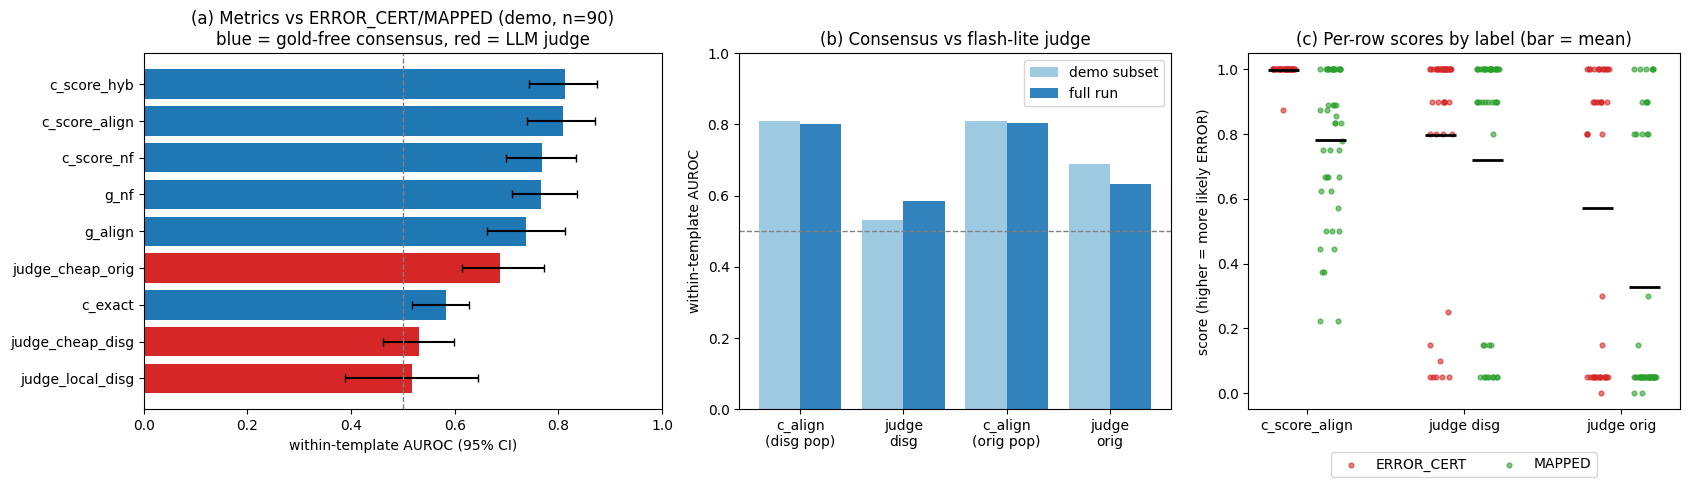

In [14]:
mt = A["metrics_on_disg_view_pop"]
names = [m for m in METRICS if mt[m]["within_template"]["est"] is not None]
est = np.array([mt[m]["within_template"]["est"] for m in names])
lo = np.array([mt[m]["within_template"]["ci"][0] for m in names])
hi = np.array([mt[m]["within_template"]["ci"][1] for m in names])
order = np.argsort(est)

fig, ax = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [1.2, 1, 1]})
# (a) within-template AUROC of every metric on the disguised-view population
cols = ["#d62728" if n.startswith("judge") else "#1f77b4" for n in np.array(names)[order]]
ax[0].barh(np.array(names)[order], est[order], xerr=[est[order] - lo[order], hi[order] - est[order]], color=cols, capsize=3)
ax[0].axvline(0.5, color="grey", ls="--", lw=1)
ax[0].set_xlim(0, 1); ax[0].set_xlabel("within-template AUROC (95% CI)")
ax[0].set_title(f"(a) Metrics vs ERROR_CERT/MAPPED (demo, n={len(P_d)})\nblue = gold-free consensus, red = LLM judge")

# (b) headline: demo vs full-run AUROCs
lab = ["c_align\n(disg pop)", "judge\ndisg", "c_align\n(orig pop)", "judge\norig"]
demo = [H["disg"]["auroc_a"], H["disg"]["auroc_b"], H["orig"]["auroc_a"], H["orig"]["auroc_b"]]
full = [ref["provisional_headline"]["disg"]["auroc_a"], ref["provisional_headline"]["disg"]["auroc_b"],
        ref["provisional_headline"]["orig"]["auroc_a"], ref["provisional_headline"]["orig"]["auroc_b"]]
x = np.arange(4)
ax[1].bar(x - 0.2, demo, 0.4, label="demo subset", color="#9ecae1")
ax[1].bar(x + 0.2, full, 0.4, label="full run", color="#3182bd")
ax[1].axhline(0.5, color="grey", ls="--", lw=1)
ax[1].set_xticks(x, lab); ax[1].set_ylim(0, 1); ax[1].set_ylabel("within-template AUROC"); ax[1].legend()
ax[1].set_title("(b) Consensus vs flash-lite judge")

# (c) score distributions by provisional label
for i, (m, P) in enumerate((("c_score_align", P_d), ("judge_cheap_disg", P_d), ("judge_cheap_orig", P_o))):
    for yv, c, off in ((1.0, "#d62728", -0.15), (0.0, "#2ca02c", 0.15)):
        v = P[P.y == yv][m].to_numpy()
        ax[2].scatter(np.full(len(v), i + off) + np.random.default_rng(0).uniform(-0.07, 0.07, len(v)), v, s=12, alpha=0.6, color=c,
                      label=({1.0: "ERROR_CERT", 0.0: "MAPPED"}[yv] if i == 0 else None))
        ax[2].hlines(np.mean(v), i + off - 0.1, i + off + 0.1, color="k", lw=2)
ax[2].set_xticks([0, 1, 2], ["c_score_align", "judge disg", "judge orig"]); ax[2].set_ylabel("score (higher = more likely ERROR)")
ax[2].set_title("(c) Per-row scores by label (bar = mean)"); ax[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout(); plt.show()

**How to read the results**
- **Confirmatory verdict: NOT_TESTABLE.** The gated label set has no CORRECT rows (FALLBACK B), so criterion (c) could not be tested as pre-registered.
- **Provisional view (ERROR_CERT vs MAPPED).** Solver consensus `c_score_align` separates the classes clearly better than the flash-lite judge in the
  disguised view. The gap shrinks in the original view, where the judge can see the dataset's real predicate names.
  On 100 rows the CIs are wide. The full run (about 1,700 rows) gives +0.217 [0.175, 0.260] and +0.171 [0.135, 0.206].
- **Nesting.** Adding `c` to the judge adds a lot of signal. Adding the judge to `c` adds little. So the consensus score carries most of the signal the judge has, and more.
- **Operating points.** The label-free majority rule (`c_score_align > 0.5`) flags almost every ERROR_CERT row. It also flags many MAPPED rows, so its
  false-alarm rate is high on this balanced subset.
- **Caveats (from the full artifact):**
  - MAPPED is not the same as CORRECT. A blind two-family audit found that MAPPED rows were faithful about 72–90% of the time.
  - The text is templated English (9 templates).
  - A frontier judge (gemini-3.1-pro) matched or beat `c_align` on 150 rows.